[INFO] Using device: cuda

 Running kappa = 0.5

--- Replicate 1/10 ---
Epoch   5 | Loss=606.426453 | Kurtosis=5.070259
Epoch  10 | Loss=573.275635 | Kurtosis=7.674129
Epoch  15 | Loss=550.701538 | Kurtosis=3.740164
Epoch  20 | Loss=546.224426 | Kurtosis=4.201897
Epoch  25 | Loss=544.223022 | Kurtosis=6.242983
Epoch  30 | Loss=544.315247 | Kurtosis=6.499993
Epoch  35 | Loss=544.200012 | Kurtosis=5.826404
Epoch  40 | Loss=543.828857 | Kurtosis=6.452285
Epoch  45 | Loss=543.311890 | Kurtosis=5.845192
Epoch  50 | Loss=541.884888 | Kurtosis=7.052491
Epoch  55 | Loss=541.992981 | Kurtosis=7.305386
Epoch  60 | Loss=542.173401 | Kurtosis=8.290380
Epoch  65 | Loss=542.641296 | Kurtosis=9.483529
Epoch  70 | Loss=543.047546 | Kurtosis=10.185795
Epoch  75 | Loss=543.234619 | Kurtosis=10.078514
Epoch  80 | Loss=544.049744 | Kurtosis=9.658581
Epoch  85 | Loss=543.879456 | Kurtosis=9.368244
Epoch  90 | Loss=544.445435 | Kurtosis=9.055100
Epoch  95 | Loss=544.270508 | Kurtosis=9.819149
Epoch 100 | Lo

ValueError: too many values to unpack (expected 3)

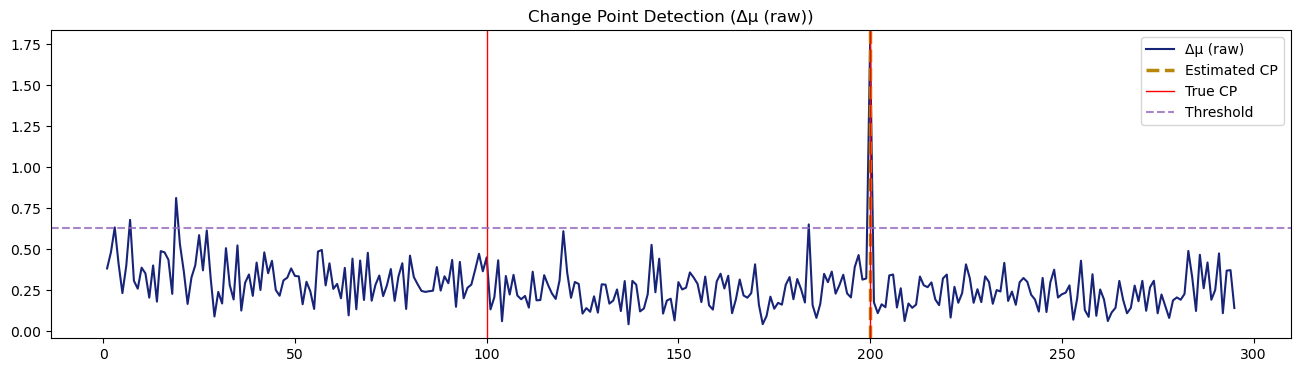

In [ ]:
import torch, random, io, sys, warnings
import os, numpy as np, pandas as pd, pyreadr
from tqdm import tqdm

import sys, os
sys.path.append(os.path.abspath(".."))

from cpd_model import parse_args, learn_one_seq_penalty

warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# ======================================================
# CONFIG
# ======================================================
REPS = 10
TRUE_CP = [100, 200]

KAPPA_LIST = [0.5, 0.8, 2]
TOL = 10

# ======================================================
# BASE ARGS
# ======================================================
base_args = parse_args()
base_args.epoch = 150
base_args.K_dim = 2
base_args.z_dim = 3
base_args.decoder_lr = 0.01
base_args.decoder_iteration = 20
base_args.langevin_s = 0.2
base_args.langevin_K = 100
base_args.kappa = 0.8
base_args.penalties = [0.01, 0.05, 0.1, 1]
base_args.nu_iteration = 20
base_args.output_layer = [50, 50]
base_args.scale_delta = False
base_args.signif_level = 0.99
base_args.true_CP_full = TRUE_CP

# ======================================================
# MAIN LOOP
# ======================================================
records = []

GLOBAL_SEED = 1

for kappa in KAPPA_LIST:

    print(f"\n==============================")
    print(f" Running kappa = {kappa}")
    print(f"==============================")

    for rep in range(1, REPS + 1):

        print(f"\n--- Replicate {rep}/{REPS} ---")

        SEED = GLOBAL_SEED + rep
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        Y = pyreadr.read_r(f"../real_data_sim/sim_dat_ult_5_{rep}.RDS")
        X = pyreadr.read_r(f"../real_data_sim/sim_x_ult_5_{rep}.RDS")

        Y_df = np.array(list(Y.values())[0])
        X_df = np.array(list(X.values())[0])

        X_rep = np.repeat(X_df[:, np.newaxis, :], 100, axis=1)
        Y = Y_df[:, :, 0:3]
        X = X_rep

        args = parse_args()
        args.__dict__.update(base_args.__dict__)

        args.kappa = kappa
        args.x_dim = X.shape[2]
        args.y_dim = Y.shape[2]
        args.num_time = X.shape[0]
        args.num_samples = X.shape[1]

        x_input = torch.tensor(X, dtype=torch.float32).to(device)
        y_input = torch.tensor(Y, dtype=torch.float32).to(device)

        odd_idx = range(1, args.num_time, 2)
        even_idx = range(0, args.num_time, 2)

        x_train = x_input[odd_idx].reshape(-1, args.x_dim)
        x_test  = x_input[even_idx].reshape(-1, args.x_dim)
        y_train = y_input[odd_idx].reshape(-1, args.y_dim)
        y_test  = y_input[even_idx].reshape(-1, args.y_dim)

        results_half = []

        for penalty in args.penalties:
            _stdout = sys.stdout
            # sys.stdout = io.StringIO()
            try:
                loss, pen = learn_one_seq_penalty(
                    args, x_train, y_train, x_test, y_test,
                    penalty=penalty, half=True
                )
            finally:
                sys.stdout = _stdout

            results_half.append([loss, pen])

        results_half = np.array(results_half)
        best_idx = np.argmin(results_half[:, 0])
        best_penalty = args.penalties[best_idx]

        print(f"[INFO] Best penalty = {best_penalty}")

        _stdout = sys.stdout
        # sys.stdout = io.StringIO()
        try:
            out = learn_one_seq_penalty(
                args,
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                penalty=best_penalty,
                half=False
            )
            result = out[0]
        finally:
            sys.stdout = _stdout

        torch.cuda.empty_cache()

        est_cp = np.array(result[5], dtype=int) if len(result[5]) > 0 else np.array([])
        true_cp = np.array(TRUE_CP)

        if len(est_cp) == 0:
            cover_rate = 0
            avg_dist = np.nan
            FP = 0
            FN = len(true_cp)
        else:
            dist_mat = np.abs(est_cp[:, None] - true_cp[None, :])
            min_dist_true = dist_mat.min(axis=0)
            min_dist_est  = dist_mat.min(axis=1)

            cover_rate = np.mean(min_dist_true <= TOL)
            avg_dist   = np.mean(min_dist_true)
            FP = np.sum(min_dist_est > TOL)
            FN = np.sum(min_dist_true > TOL)
        
        records.append({
            "kappa": kappa,
            "rep": rep,
            "best_penalty": best_penalty,
            "num_detected": len(est_cp),

            # core output
            "est_CP": str(list(est_cp)),
            "true_CP": str(TRUE_CP),

            # optional debug
            "CE": result[0],
        })

df = pd.DataFrame(records)
df.to_csv("cpd_kappa_experiment.csv", index=False)
